<a href="https://colab.research.google.com/github/prnakyazze94/Data-608/blob/main/Story%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import json
import csv
from datetime import datetime

# --- CONFIGURATION ---
#  KEY
API_KEY = "00c7eba3d65642c88329d9c48e12db20"

# Series IDs:
# CUUR0000SA0 = CPI-All Urban Consumers (Index 1982-84=100)
# LNS14000000 = Unemployment Rate (Seasonally Adjusted)
SERIES_IDS = ["CUUR0000SA0", "LNS14000000"]

# BLS API v2 Endpoint
URL = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

def get_bls_data(start_year, end_year):
    headers = {'Content-type': 'application/json'}
    data = json.dumps({
        "seriesid": SERIES_IDS,
        "startyear": str(start_year),
        "endyear": str(end_year),
        "registrationkey": API_KEY
    })

    print(f"Requesting data from {start_year} to {end_year}...")
    response = requests.post(URL, data=data, headers=headers)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"HTTP Error: {response.status_code}")
        return None

def process_data(json_data, all_records):
    """
    Extract data and appends it to our main list.
    """
    # Check for API messageS
    if 'message' in json_data and json_data['message']:
        for msg in json_data['message']:
            print(f"  BLS Message: {msg}")

    if 'Results' not in json_data or 'series' not in json_data['Results']:
        print("  -> No data returned for this batch.")
        return

    series_list = json_data['Results']['series']

    for series in series_list:
        series_id = series['seriesID']
        data_points = series.get('data', [])

        # Map ID to readable name
        series_name = "CPI (Consumer Price Index)" if series_id == "CUUR0000SA0" else "Unemployment Rate"

        for item in data_points:
            # Flatten the structure for CSV
            record = {
                "Series ID": series_id,
                "Series Name": series_name,
                "Year": item['year'],
                "Period": item['period'],
                "Period Name": item['periodName'],
                "Value": item['value']
            }
            all_records.append(record)

# --- MAIN EXECUTION ---
current_year = datetime.now().year
start_year_total = current_year - 25

# Split request into chunks (max 20 years per request)
chunks = [
    (start_year_total, start_year_total + 19),
    (start_year_total + 20, current_year)
]

all_records = []

print("Starting BLS Data Retrieval...")

for start, end in chunks:
    if start > current_year: continue
    end = min(end, current_year)

    result = get_bls_data(start, end)
    if result:
        process_data(result, all_records)

# --- SAVE TO CSV ---
if all_records:
    filename = "bls_data_25_years.csv"
    keys = all_records[0].keys()

    with open(filename, 'w', newline='') as output_file:
        dict_writer = csv.DictWriter(output_file, fieldnames=keys)
        dict_writer.writeheader()
        dict_writer.writerows(all_records)

    print(f"\nSuccess! Retrieved {len(all_records)} data points.")
    print(f"Data saved to: {filename}")
else:
    print("\nNo data was retrieved. Please check your API key limits.")

Starting BLS Data Retrieval...
Requesting data from 2001 to 2020...
Requesting data from 2021 to 2026...

Success! Retrieved 602 data points.
Data saved to: bls_data_25_years.csv


Fetching data from FRED (St. Louis Fed)...

Success! Data saved to: fed_funds_rate_25_years.csv
Records retrieved: 299


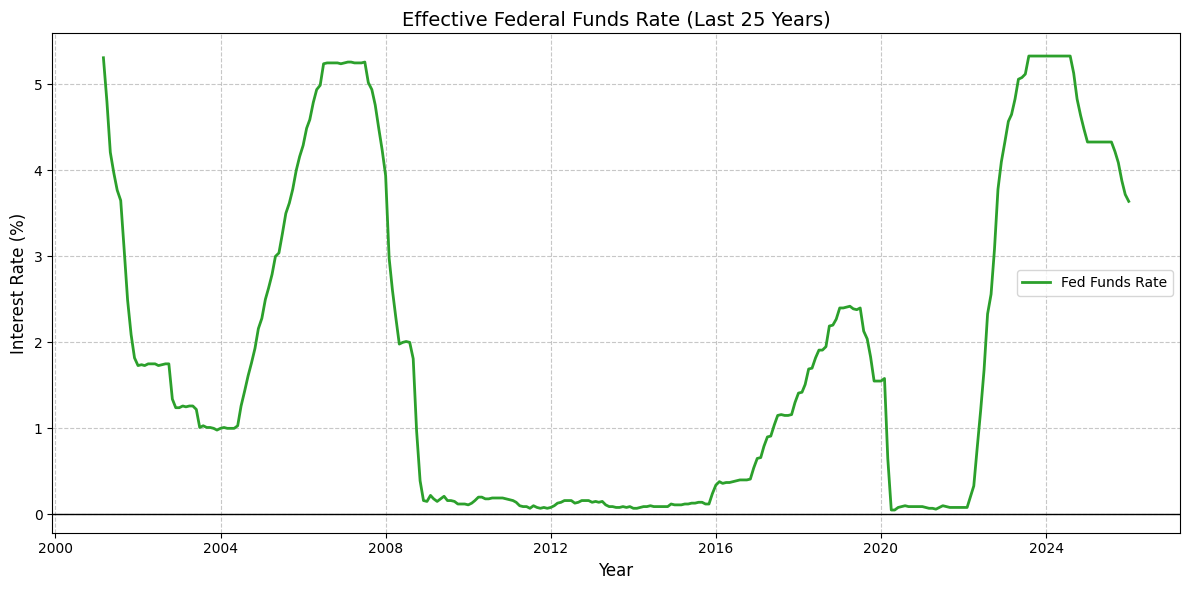

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import io
from datetime import datetime, timedelta

# --- CONFIGURATION ---
SERIES_ID = "FEDFUNDS"
URL = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={SERIES_ID}"

print("Fetching data from FRED (St. Louis Fed)...")

# 1. Set up headers to mimic a standard web browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

# 2. Fetch the data using requests
response = requests.get(URL, headers=headers)

# 3. Check if the request was successful
if response.status_code == 200:
    csv_data = io.StringIO(response.text)

    try:
        # UPDATED: Now looking for 'observation_date' instead of 'DATE'
        df = pd.read_csv(csv_data, parse_dates=['observation_date'], index_col='observation_date')

        # Filter for the last 25 years
        start_date = datetime.now() - timedelta(days=25*365)
        df_recent = df[df.index >= start_date].copy()

        # Clean up and rename
        df_recent.rename(columns={SERIES_ID: 'Fed Funds Rate (%)'}, inplace=True)

        # Save to CSV
        csv_filename = "fed_funds_rate_25_years.csv"
        df_recent.to_csv(csv_filename)
        print(f"\nSuccess! Data saved to: {csv_filename}")
        print(f"Records retrieved: {len(df_recent)}")

        # --- VISUALIZATION ---
        plt.figure(figsize=(12, 6))
        plt.plot(df_recent.index, df_recent['Fed Funds Rate (%)'], color='#2ca02c', linewidth=2, label='Fed Funds Rate')

        plt.title('Effective Federal Funds Rate (Last 25 Years)', fontsize=14)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Interest Rate (%)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.axhline(0, color='black', linewidth=1) # Highlights the zero line
        plt.tight_layout()
        plt.show()

    except ValueError as e:
        print("\nFailed to parse the CSV.")
        print(f"Error: {e}")
else:
    print(f"\nFailed to fetch data. HTTP Status Code: {response.status_code}")

In [ ]:
import pandas as pd

# 1. Load the data from the CSV you created earlier
filename = 'bls_data_25_years.csv'
print(f"Loading data from {filename}...\n")
df = pd.read_csv(filename)

# 2. Ensure the 'Value' column is treated as numeric numbers
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# 3. Group by 'Year' and 'Series Name', then calculate the average (mean)
annual_avg = df.groupby(['Year', 'Series Name'])['Value'].mean().reset_index()

# 4. Pivot the table so 'Year' is the row, and 'CPI' & 'Unemployment' are the columns
pivot_df = annual_avg.pivot(index='Year', columns='Series Name', values='Value')

# Remove the 'Series Name' label from the top of the columns for a cleaner look
pivot_df.columns.name = None

# Round the values to 2 decimal places for neatness
pivot_df = pivot_df.round(2)

# 5. Print the results
print("Average CPI and Unemployment Rate by Year:")
print("-" * 50)
print(pivot_df.to_string())

# 6. Save this summary to a new CSV file
output_filename = 'bls_annual_averages.csv'
pivot_df.to_csv(output_filename)
print(f"\nSuccess! Saved annual averages to: {output_filename}")

Loading data from bls_data_25_years.csv...

Average CPI and Unemployment Rate by Year:
--------------------------------------------------
      CPI (Consumer Price Index)  Unemployment Rate
Year                                               
2001                      177.07               4.74
2002                      179.88               5.78
2003                      183.96               5.99
2004                      188.88               5.54
2005                      195.29               5.08
2006                      201.59               4.61
2007                      207.34               4.62
2008                      215.30               5.80
2009                      214.54               9.28
2010                      218.06               9.61
2011                      224.94               8.93
2012                      229.59               8.08
2013                      232.96               7.36
2014                      236.74               6.16
2015                      237.

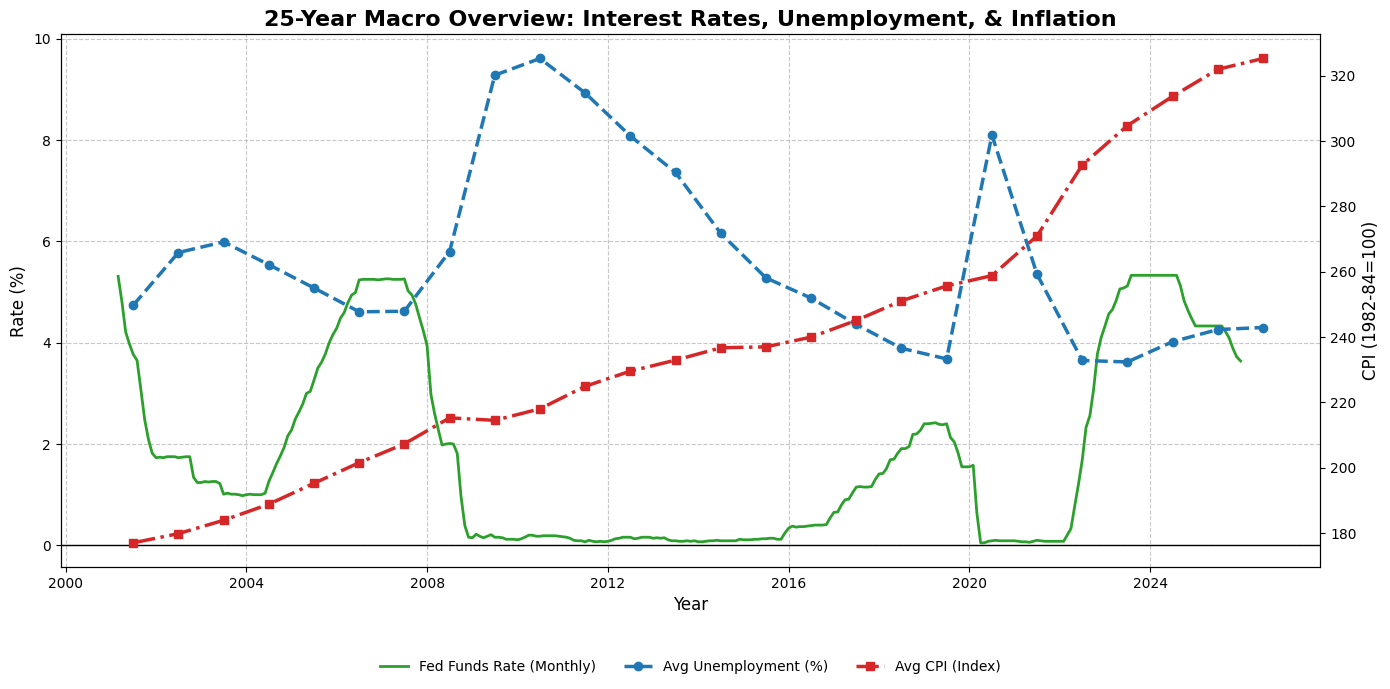

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load both datasets
df_fed = pd.read_csv('fed_funds_rate_25_years.csv', parse_dates=['observation_date'], index_col='observation_date')
df_bls = pd.read_csv('bls_annual_averages.csv')

# 2. Map the BLS Annual Year to a Date
# We assign the annual average to July 1st ('-07-01') so the data points
# sit perfectly in the middle of each year on the chart's timeline.
df_bls['Date'] = pd.to_datetime(df_bls['Year'].astype(str) + '-07-01')
df_bls.set_index('Date', inplace=True)

# 3. Set up the canvas
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- LEFT AXIS: Rates (%) ---
# Plot 1: Monthly Fed Funds Rate (Green Line)
ax1.plot(df_fed.index, df_fed['Fed Funds Rate (%)'], color='#2ca02c', linewidth=2, label='Fed Funds Rate (Monthly)')

# Plot 2: Annual Average Unemployment Rate (Blue Dashed Line with Dots)
ax1.plot(df_bls.index, df_bls['Unemployment Rate'], color='tab:blue', linewidth=2.5, marker='o', linestyle='--', label='Avg Unemployment (%)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Rate (%)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(0, color='black', linewidth=1) # Highlight the zero line

# --- RIGHT AXIS: CPI (Index Number) ---
ax2 = ax1.twinx()

# Plot 3: Annual Average CPI (Red Dotted Line with Squares)
ax2.plot(df_bls.index, df_bls['CPI (Consumer Price Index)'], color='tab:red', linewidth=2.5, marker='s', linestyle='-.', label='Avg CPI (Index)')
ax2.set_ylabel('CPI (1982-84=100)', fontsize=12)

# --- COMBINED LEGEND ---
# Gather lines and labels from both axes to create one unified legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Place the legend slightly below the chart so it doesn't block the lines
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

# Add title and adjust layout
plt.title('25-Year Macro Overview: Interest Rates, Unemployment, & Inflation', fontsize=16, fontweight='bold')
plt.tight_layout()

# Show the plot
plt.show()

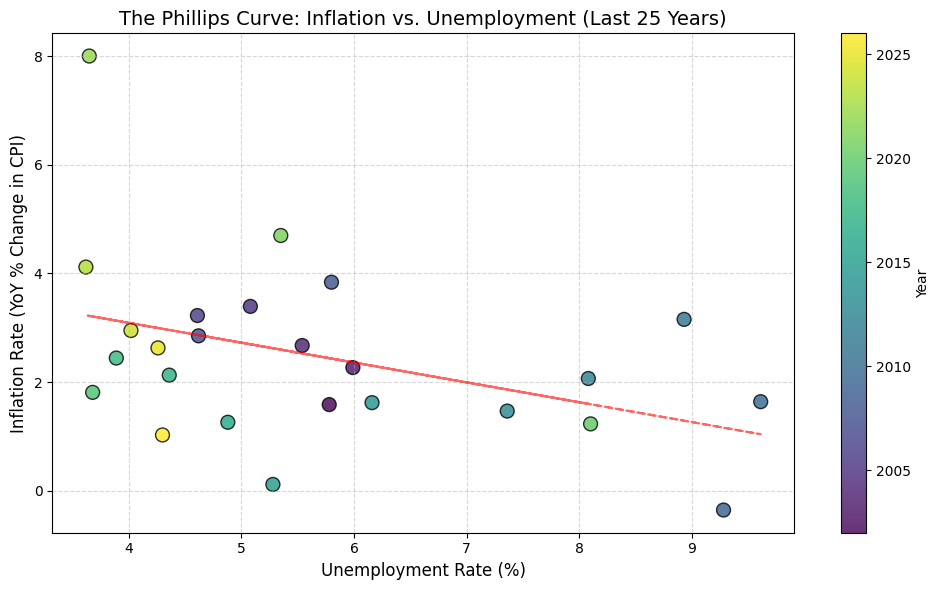

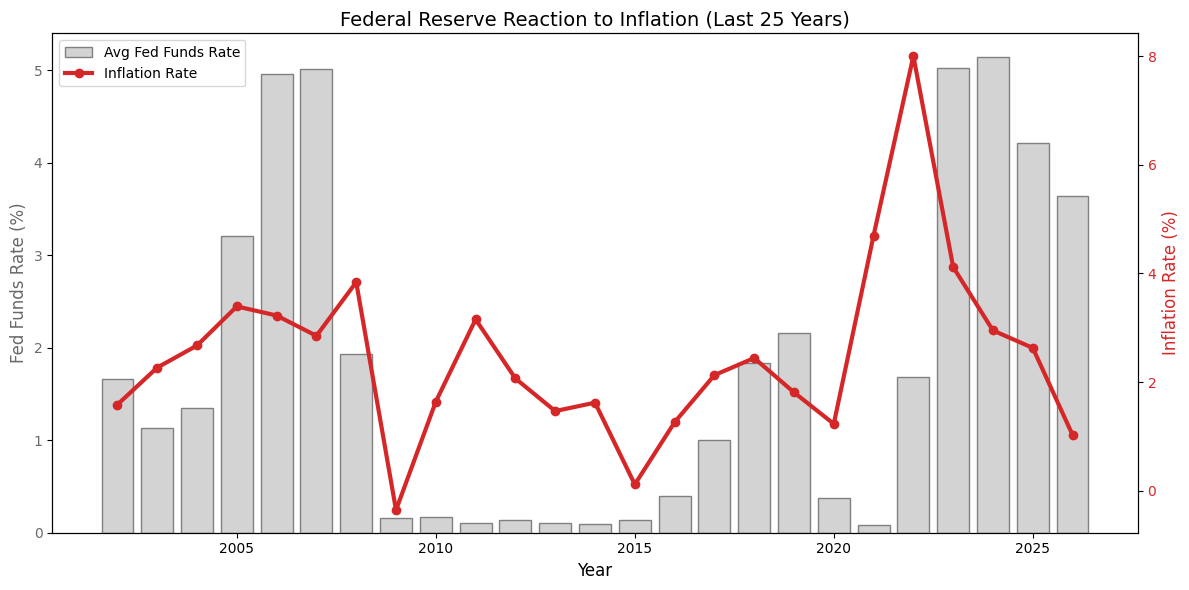

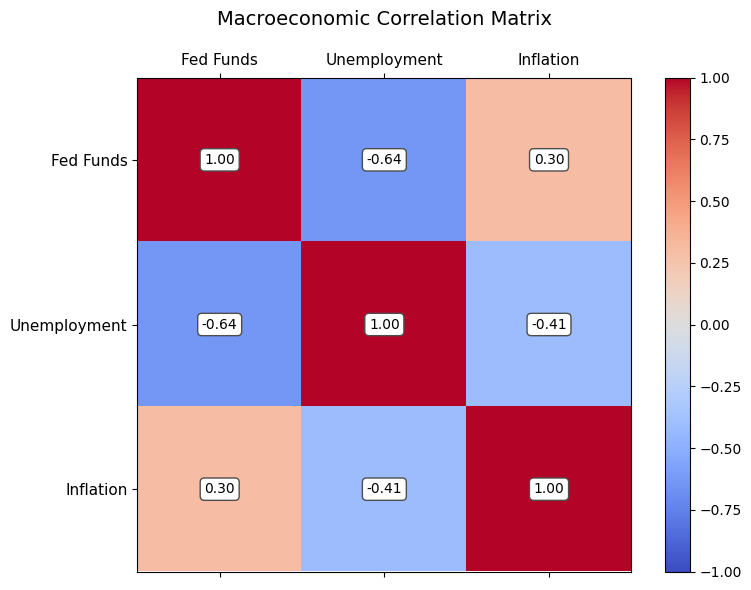

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ---------------------------------------------------------
# Load BLS Annual Data (Year, CPI, Unemployment)
df_bls = pd.read_csv('bls_annual_averages.csv')

# Calculate Inflation Rate (Year-over-Year % Change in CPI)
# Using pct_change() calculates the difference from the previous year
df_bls['Inflation Rate (%)'] = df_bls['CPI (Consumer Price Index)'].pct_change() * 100

# Load Fed Funds Monthly Data
df_fed = pd.read_csv('fed_funds_rate_25_years.csv', parse_dates=['observation_date'])
df_fed['Year'] = df_fed['observation_date'].dt.year

# Convert Monthly Fed data to Annual Averages to match BLS data
df_fed_annual = df_fed.groupby('Year')['Fed Funds Rate (%)'].mean().reset_index()

# Merge everything into one Master DataFrame
df_master = pd.merge(df_bls, df_fed_annual, on='Year')
# Drop the first year (usually 2001) because it won't have a YoY Inflation calculation
df_master = df_master.dropna()

# ---------------------------------------------------------
# 2. VISUALIZATION 1: The Phillips Curve (Scatter Plot)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df_master['Unemployment Rate'], df_master['Inflation Rate (%)'],
            c=df_master['Year'], cmap='viridis', s=100, edgecolor='black', alpha=0.8)

# Add a trendline
z = np.polyfit(df_master['Unemployment Rate'], df_master['Inflation Rate (%)'], 1)
p = np.poly1d(z)
plt.plot(df_master['Unemployment Rate'], p(df_master['Unemployment Rate']), "r--", alpha=0.6)

plt.colorbar(label='Year')
plt.title('The Phillips Curve: Inflation vs. Unemployment (Last 25 Years)', fontsize=14)
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Inflation Rate (YoY % Change in CPI)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. VISUALIZATION 2: Fed Funds Rate vs. Inflation
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Fed Funds as Bars
ax1.bar(df_master['Year'], df_master['Fed Funds Rate (%)'], color='lightgray', edgecolor='gray', label='Avg Fed Funds Rate')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Fed Funds Rate (%)', fontsize=12, color='dimgray')
ax1.tick_params(axis='y', labelcolor='dimgray')

# Plot Inflation as a Line on a secondary axis
ax2 = ax1.twinx()
ax2.plot(df_master['Year'], df_master['Inflation Rate (%)'], color='tab:red', linewidth=3, marker='o', label='Inflation Rate')
ax2.set_ylabel('Inflation Rate (%)', fontsize=12, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combined Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Federal Reserve Reaction to Inflation (Last 25 Years)', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. VISUALIZATION 3: Correlation Matrix (Heatmap)
# ---------------------------------------------------------
# Select only the numerical columns we care about
cols_to_correlate = ['Fed Funds Rate (%)', 'Unemployment Rate', 'Inflation Rate (%)']
corr_matrix = df_master[cols_to_correlate].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

# Set labels
ax.set_xticks(np.arange(len(cols_to_correlate)))
ax.set_yticks(np.arange(len(cols_to_correlate)))
ax.set_xticklabels(['Fed Funds', 'Unemployment', 'Inflation'], fontsize=11)
ax.set_yticklabels(['Fed Funds', 'Unemployment', 'Inflation'], fontsize=11)

# Annotate with the correlation values
for (i, j), z in np.ndenumerate(corr_matrix):
    ax.text(j, i, f'{z:0.2f}', ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.3'))

plt.title('Macroeconomic Correlation Matrix', pad=20, fontsize=14)
plt.tight_layout()
plt.show()

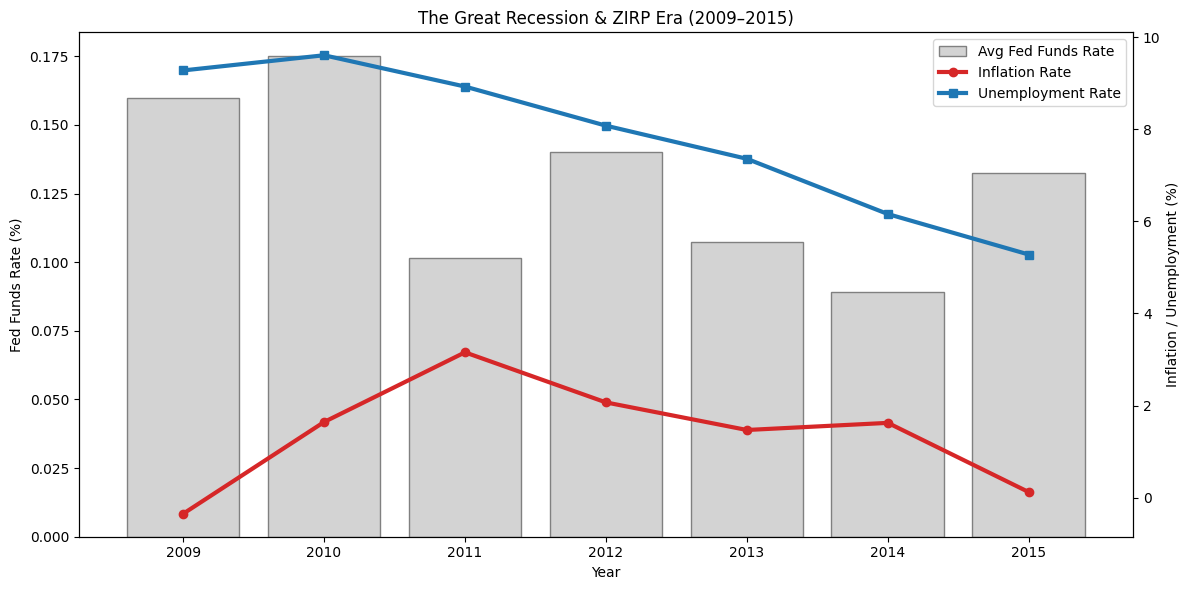

In [ ]:
# ---------------------------------------------------------
# VISUALIZATION 4A: The Great Recession (2009–2015)
# ---------------------------------------------------------
df_recession = df_master[(df_master['Year'] >= 2009) & (df_master['Year'] <= 2015)]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Fed Funds Rate (Bars)
ax1.bar(
    df_recession['Year'],
    df_recession['Fed Funds Rate (%)'],
    color='lightgray',
    edgecolor='gray',
    label='Avg Fed Funds Rate'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Fed Funds Rate (%)')

# Inflation (Red Line)
ax2 = ax1.twinx()
ax2.plot(
    df_recession['Year'],
    df_recession['Inflation Rate (%)'],
    color='tab:red',
    linewidth=3,
    marker='o',
    label='Inflation Rate'
)

# Unemployment (Blue Line)
ax2.plot(
    df_recession['Year'],
    df_recession['Unemployment Rate'],
    color='tab:blue',
    linewidth=3,
    marker='s',
    label='Unemployment Rate'
)

ax2.set_ylabel('Inflation / Unemployment (%)')

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('The Great Recession & ZIRP Era (2009–2015)')
plt.tight_layout()
plt.show()

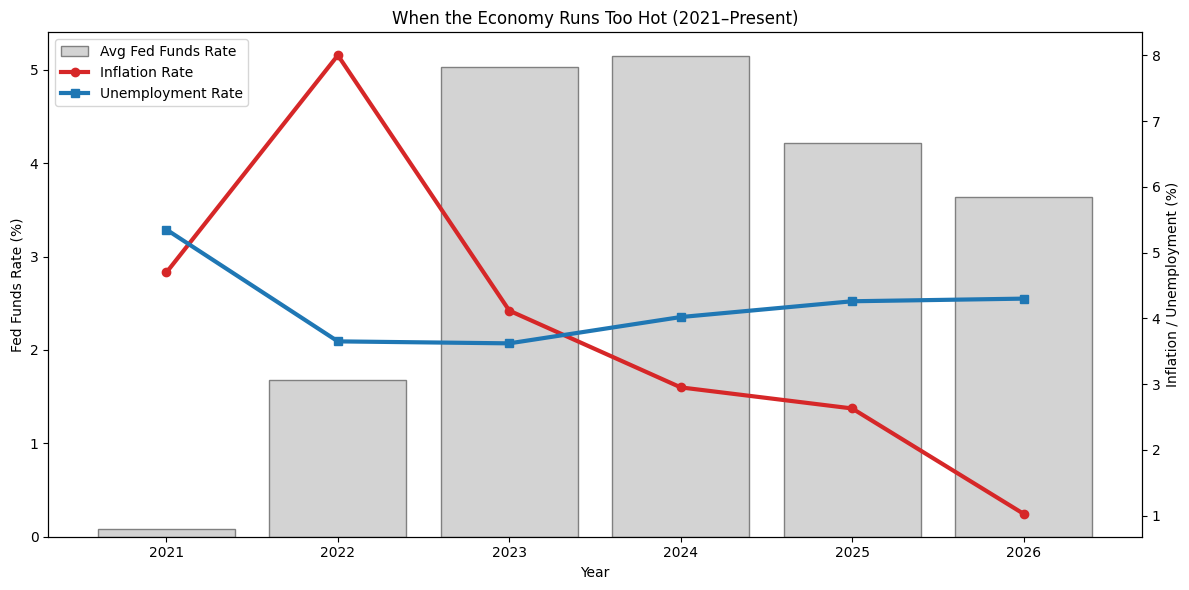

In [ ]:
# ---------------------------------------------------------
# VISUALIZATION 4B: Economy Running Too Hot (2021–Present)
# ---------------------------------------------------------
df_hot = df_master[df_master['Year'] >= 2021]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Fed Funds Rate (Bars)
ax1.bar(
    df_hot['Year'],
    df_hot['Fed Funds Rate (%)'],
    color='lightgray',
    edgecolor='gray',
    label='Avg Fed Funds Rate'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Fed Funds Rate (%)')

# Inflation (Red Line)
ax2 = ax1.twinx()
ax2.plot(
    df_hot['Year'],
    df_hot['Inflation Rate (%)'],
    color='tab:red',
    linewidth=3,
    marker='o',
    label='Inflation Rate'
)

# Unemployment (Blue Line)
ax2.plot(
    df_hot['Year'],
    df_hot['Unemployment Rate'],
    color='tab:blue',
    linewidth=3,
    marker='s',
    label='Unemployment Rate'
)

ax2.set_ylabel('Inflation / Unemployment (%)')

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('When the Economy Runs Too Hot (2021–Present)')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.line(
    df_master,
    x='Year',
    y=['Inflation Rate (%)', 'Unemployment Rate'],
    title='Federal Reserve Dual Mandate: Inflation vs Unemployment',
    color_discrete_map={
        'Inflation Rate (%)': 'red',
        'Unemployment Rate': 'blue'
    }
)

# Target lines
fig.add_hline(
    y=2,
    line_dash="dash",
    annotation_text="Inflation Target (2%)",
    annotation_position="top left"
)

fig.add_hline(
    y=4.5,
    line_dash="dot",
    annotation_text="Natural Unemployment (~4.5%)",
    annotation_position="bottom left"
)

fig.show()



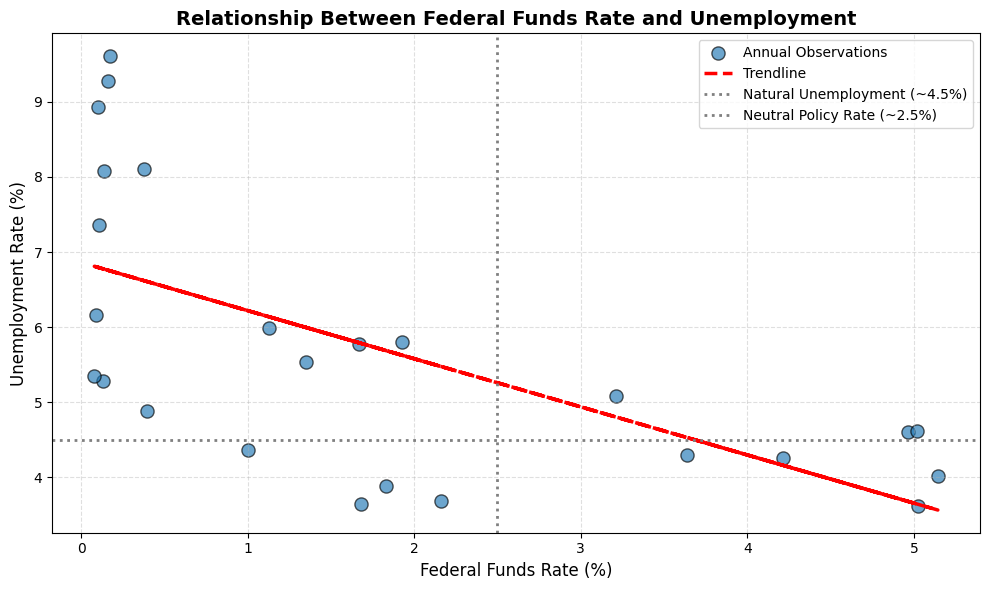

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Clean Scatter Plot: Fed Funds Rate vs Unemployment
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter points (single color, transparent)
ax.scatter(
    df_master['Fed Funds Rate (%)'],
    df_master['Unemployment Rate'],
    color='tab:blue',
    s=90,
    alpha=0.65,
    edgecolor='black',
    label='Annual Observations'
)

# Trendline
z = np.polyfit(
    df_master['Fed Funds Rate (%)'],
    df_master['Unemployment Rate'],
    1
)
p = np.poly1d(z)

ax.plot(
    df_master['Fed Funds Rate (%)'],
    p(df_master['Fed Funds Rate (%)']),
    color='red',
    linestyle='--',
    linewidth=2.5,
    label='Trendline'
)

# Reference lines (economic benchmarks)
ax.axhline(
    y=4.5,
    color='gray',
    linestyle=':',
    linewidth=2,
    label='Natural Unemployment (~4.5%)'
)

ax.axvline(
    x=2.5,
    color='gray',
    linestyle=':',
    linewidth=2,
    label='Neutral Policy Rate (~2.5%)'
)

# Labels and title
ax.set_title(
    'Relationship Between Federal Funds Rate and Unemployment',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Federal Funds Rate (%)', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)

# Styling
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

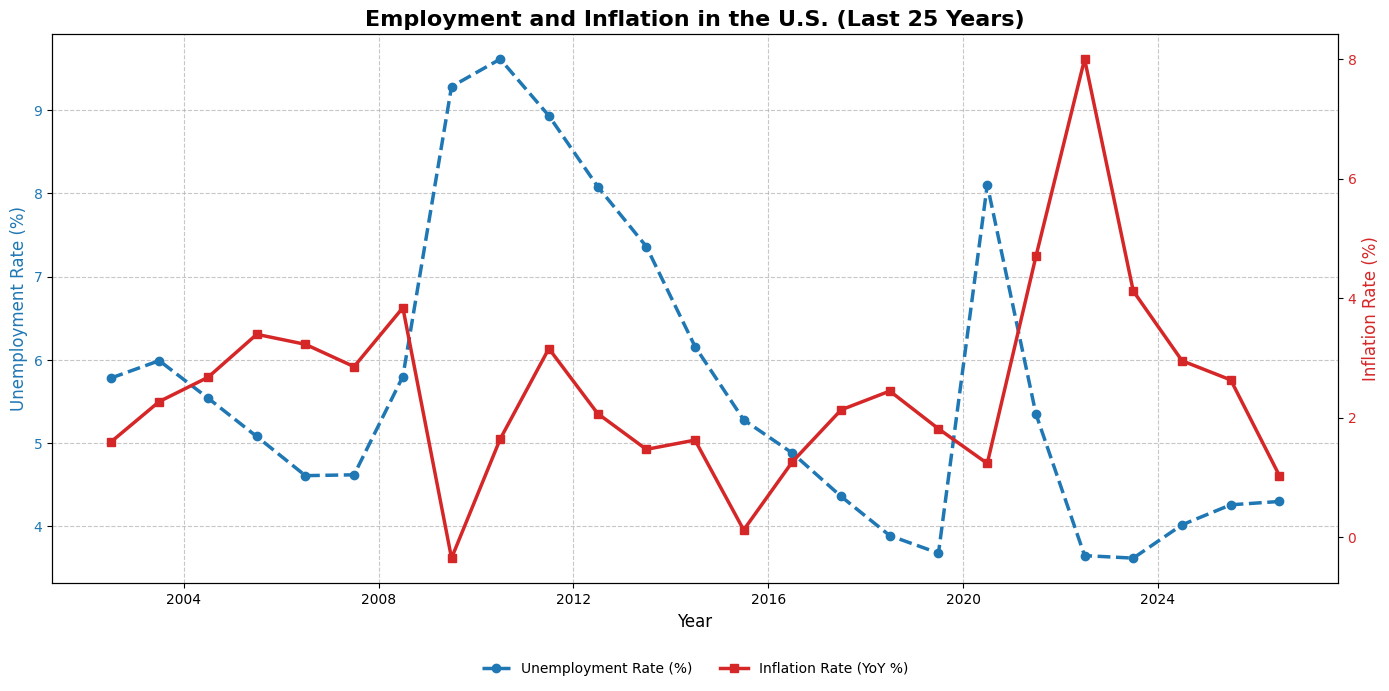

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load BLS data
# ---------------------------------------------------------
df_bls = pd.read_csv('bls_annual_averages.csv')

# ---------------------------------------------------------
# 2. Map Year to Mid-Year Date
# ---------------------------------------------------------
df_bls['Date'] = pd.to_datetime(df_bls['Year'].astype(str) + '-07-01')
df_bls.set_index('Date', inplace=True)

# ---------------------------------------------------------
# 3. Calculate Inflation Rate (YoY % change in CPI)
# ---------------------------------------------------------
df_bls['Inflation Rate (%)'] = (
    df_bls['CPI (Consumer Price Index)']
    .pct_change() * 100
)

df_bls = df_bls.dropna()

# ---------------------------------------------------------
# 4. Plot: Employment vs Inflation
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 7))

# Unemployment (Left Axis)
ax1.plot(
    df_bls.index,
    df_bls['Unemployment Rate'],
    color='tab:blue',
    linewidth=2.5,
    marker='o',
    linestyle='--',
    label='Unemployment Rate (%)'
)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Unemployment Rate (%)', fontsize=12, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.7)

# Inflation (Right Axis)
ax2 = ax1.twinx()
ax2.plot(
    df_bls.index,
    df_bls['Inflation Rate (%)'],
    color='tab:red',
    linewidth=2.5,
    marker='s',
    linestyle='-',
    label='Inflation Rate (YoY %)'
)

ax2.set_ylabel('Inflation Rate (%)', fontsize=12, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# ---------------------------------------------------------
# 5. Combined Legend
# ---------------------------------------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

# Title
plt.title(
    'Employment and Inflation in the U.S. (Last 25 Years)',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2757655782.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2757655782.py:48: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


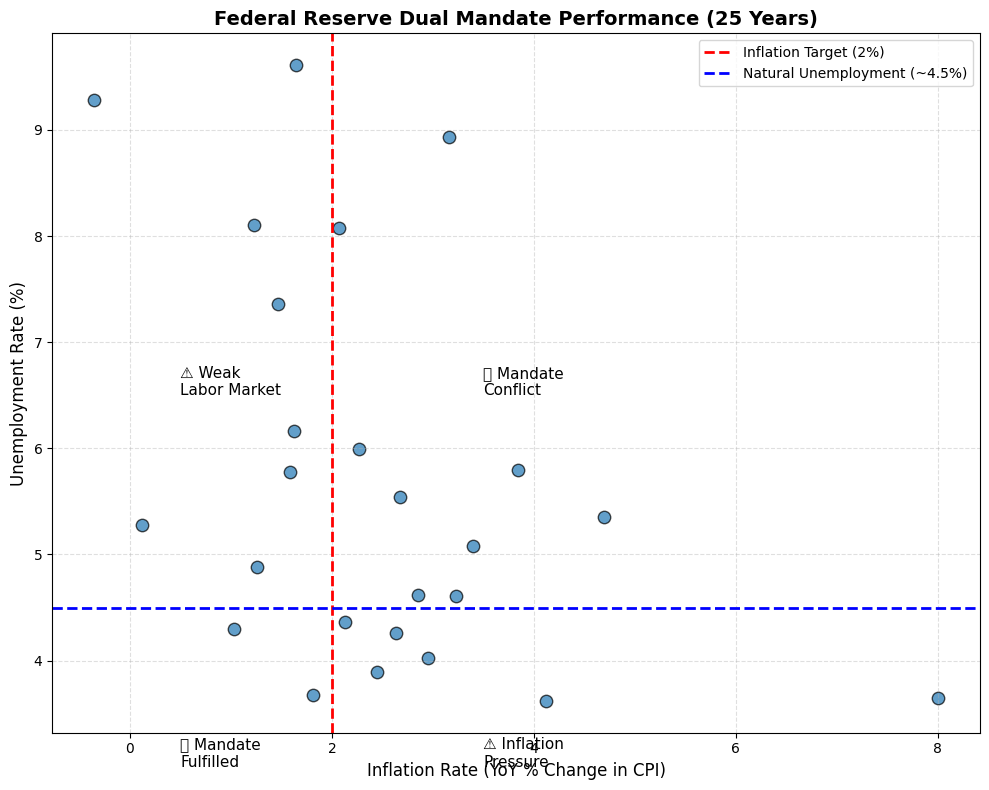

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load BLS data
df = pd.read_csv('bls_annual_averages.csv')

# Calculate inflation
df['Inflation Rate (%)'] = (
    df['CPI (Consumer Price Index)'].pct_change() * 100
)
df = df.dropna()

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    df['Inflation Rate (%)'],
    df['Unemployment Rate'],
    color='tab:blue',
    s=80,
    alpha=0.7,
    edgecolor='black'
)

# Mandate reference lines
ax.axvline(2, color='red', linestyle='--', linewidth=2, label='Inflation Target (2%)')
ax.axhline(4.5, color='blue', linestyle='--', linewidth=2, label='Natural Unemployment (~4.5%)')

# Quadrant labels
ax.text(0.5, 3, '✅ Mandate\nFulfilled', fontsize=11)
ax.text(3.5, 3, '⚠️ Inflation\nPressure', fontsize=11)
ax.text(0.5, 6.5, '⚠️ Weak\nLabor Market', fontsize=11)
ax.text(3.5, 6.5, '❌ Mandate\nConflict', fontsize=11)

# Labels
ax.set_title(
    'Federal Reserve Dual Mandate Performance (25 Years)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Inflation Rate (YoY % Change in CPI)', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()